In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### QoF

In [2]:
def QoF(y_true, y_pred, model):
        
    #y_true = y_true.numpy().flatten()
    #y_pred = y_pred.numpy().flatten()

    n = len(y_true)
    #p = sum(p.numel() for p in model.parameters() if p.requires_grad)

    residuals = y_true - y_pred
    sse = np.sum(residuals**2)
    sst = np.sum((y_true - np.mean(y_true))**2)

    mse = sse / n
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    r2 = 1 - sse / sst
    
    #aic = n * np.log(sse / n) + 2 * p
    #bic = n * np.log(sse / n) + p * np.log(n)
     
    metrics = {"rSq": r2, 
                "sst": sst,
                "sse": sse,
                "mse": mse,
                "rmse": rmse,
                "mae": mae,
                "m": n
                #"aic": aic,
                #"bic": bic
              }
    
    return metrics

### Plot 

In [3]:
def plot(y_true, y_pred, name):
    
    #y_true = y_true.numpy().flatten()
    #y_pred = y_pred.numpy().flatten()
    
    idx = np.argsort(y_true)
    y_true_sorted = y_true[idx]
    y_pred_sorted = y_pred[idx]

    plt.figure(figsize=(8,5))
    plt.plot(y_pred_sorted, 'r.-', alpha=0.7, label="Predicted")
    plt.plot(y_true_sorted, 'k-', linewidth=2, label="True")
    
    title = name + ": yy black/actual vs. yp red/predicted" 
    plt.xlabel("Index")
    plt.ylabel("Charges")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    
    plt.savefig(
    "insurance_in_sample_0.05.jpg",        # filename (can be .png, .pdf, .jpg, .svg, etc.)
    dpi=300,           # resolution (higher = better quality)
    bbox_inches='tight',  # removes extra whitespace
    transparent=True   # optional: transparent background
    )

    #plt.show()
    
#plot(y_true, y_pred, "US Health Insurance Dataset NN, In-Sample")

## Load data

In [14]:
df = pd.read_csv("Full_Pipeline/Insurance_Charges/cleaned_insurance_with_intercept.csv")

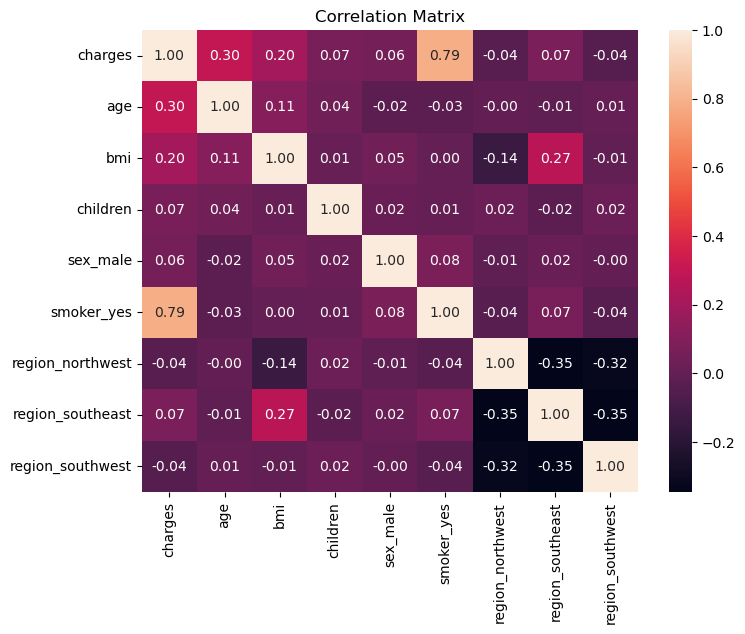

In [16]:
cols = ['charges','age','bmi','children','sex_male','smoker_yes','region_northwest','region_southeast','region_southwest']

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [17]:
X = df.drop(columns=['charges'])

y = df['charges']

In [18]:
from sklearn.model_selection import train_test_split

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.8, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest:
MAE: 2956.7923371477714
RMSE: 5056.020242853598
R2: 0.8225083593592852


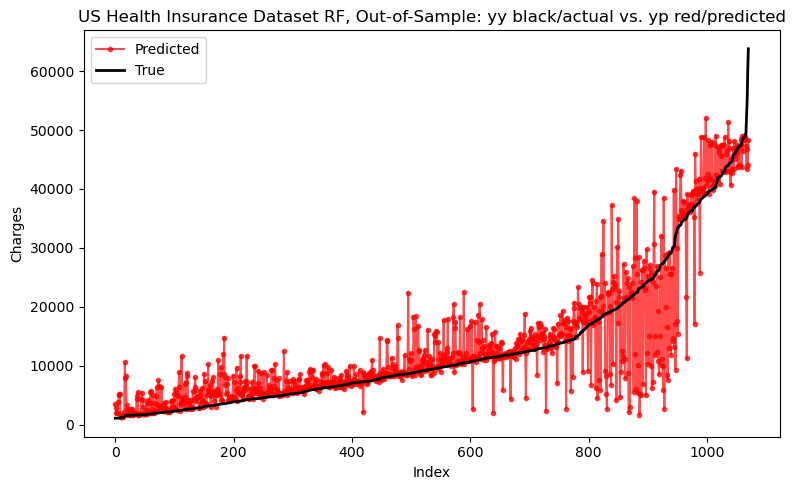

In [20]:
plot(y_test.values, rf_pred, "US Health Insurance Dataset RF, Out-of-Sample")

In [21]:
QoF(y_test.values, rf_pred, None)

{'rSq': 0.8225083593592852,
 'sst': 154251421569.71732,
 'sse': 27378337885.571674,
 'mse': 25563340.696145356,
 'rmse': 5056.020242853598,
 'mae': 2956.7923371477714,
 'm': 1071}

# Hyperparameter Tuning

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': [200, 300, 400, 500, 700],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

rf_rand = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rf_rand.fit(X_train, y_train)

print("Best params:", rf_rand.best_params_)

Best params: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'bootstrap': False}


# Tuned Model Performance

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rf = rf_rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("Tuned RF MAE:", mean_absolute_error(y_test, best_rf_pred))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, best_rf_pred)))
print("Tuned RF R2:", r2_score(y_test, best_rf_pred))

Tuned RF MAE: 3087.9428686341853
Tuned RF RMSE: 5141.698517661322
Tuned RF R2: 0.8164419175052696


# Feature Importance

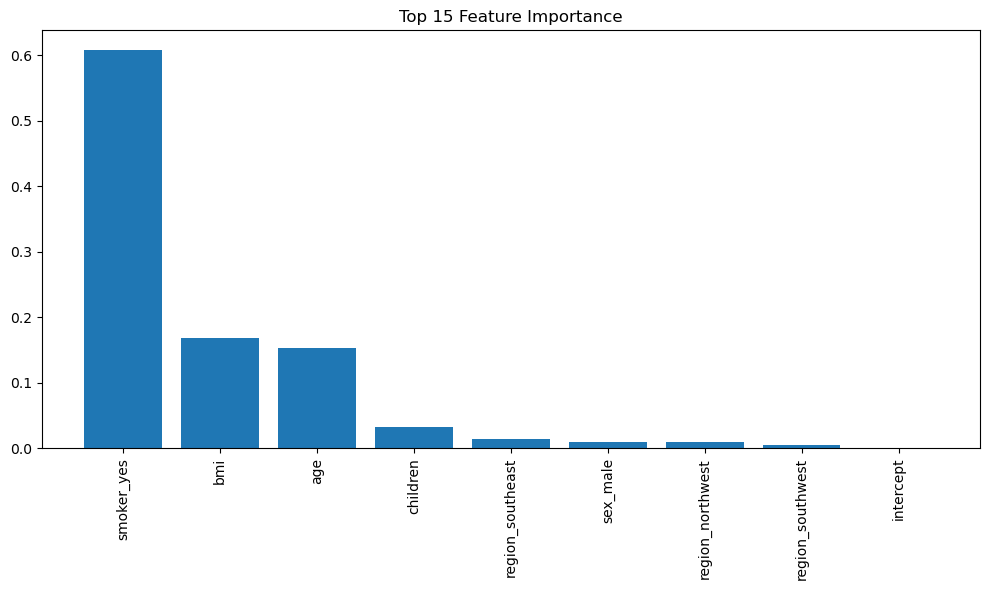

In [24]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.title("Top 15 Feature Importance")
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), X_encoded.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

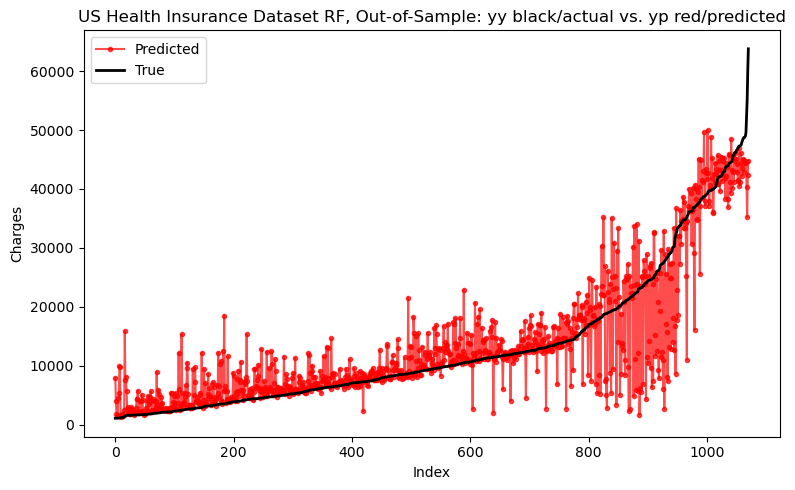

In [25]:
plot(y_test.values, best_rf_pred, "US Health Insurance Dataset RF, Out-of-Sample")

In [26]:
QoF(y_test.values, best_rf_pred, None)

{'rSq': 0.8164419175052696,
 'sst': 154251421569.71732,
 'sse': 28314095165.4236,
 'mse': 26437063.646520633,
 'rmse': 5141.698517661322,
 'mae': 3087.9428686341853,
 'm': 1071}